In [ ]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
from vae_model import VAE, vae_loss
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


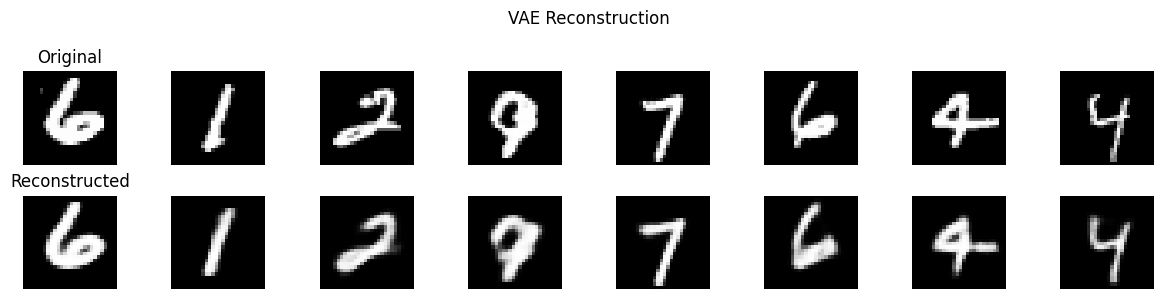

In [4]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


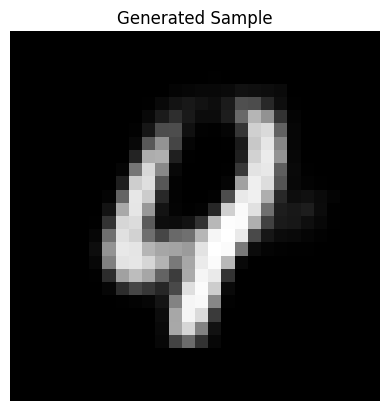

In [14]:
model.eval()
latent_dim = model.latent_dim  

z = torch.randn(1, latent_dim).to(device)

with torch.no_grad():
    x_gen = model.decoder(z).view(1, 1, 28, 28).cpu()

plt.imshow(x_gen[0, 0], cmap='gray')
plt.title("Generated Sample")
plt.axis("off")
plt.show()

In [26]:
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Use only the first 10,000 samples
train_dataset = Subset(full_dataset, range(10000))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1, Loss: 245.8726
Epoch 2, Loss: 176.7053
Epoch 3, Loss: 153.5832
Epoch 4, Loss: 142.5994
Epoch 5, Loss: 134.7361
Epoch 6, Loss: 129.4968
Epoch 7, Loss: 125.7435
Epoch 8, Loss: 122.8110
Epoch 9, Loss: 120.3738
Epoch 10, Loss: 118.5715
Epoch 11, Loss: 117.0311
Epoch 12, Loss: 115.8844
Epoch 13, Loss: 114.8752
Epoch 14, Loss: 113.9137
Epoch 15, Loss: 113.2333
Epoch 16, Loss: 112.7171
Epoch 17, Loss: 111.9027
Epoch 18, Loss: 111.2794
Epoch 19, Loss: 110.8216
Epoch 20, Loss: 110.3332
Epoch 21, Loss: 110.0510
Epoch 22, Loss: 109.6454
Epoch 23, Loss: 109.2273
Epoch 24, Loss: 108.9479
Epoch 25, Loss: 108.5810
Epoch 26, Loss: 108.2380
Epoch 27, Loss: 107.9956
Epoch 28, Loss: 107.8333
Epoch 29, Loss: 107.6665
Epoch 30, Loss: 107.3862
Epoch 31, Loss: 107.0684
Epoch 32, Loss: 106.8885
Epoch 33, Loss: 106.8293
Epoch 34, Loss: 106.5570
Epoch 35, Loss: 106.4162
Epoch 36, Loss: 106.2893
Epoch 37, Loss: 106.1232
Epoch 38, Loss: 105.8920
Epoch 39, Loss: 105.7018
Epoch 40, Loss: 105.6831
Epoch 41,

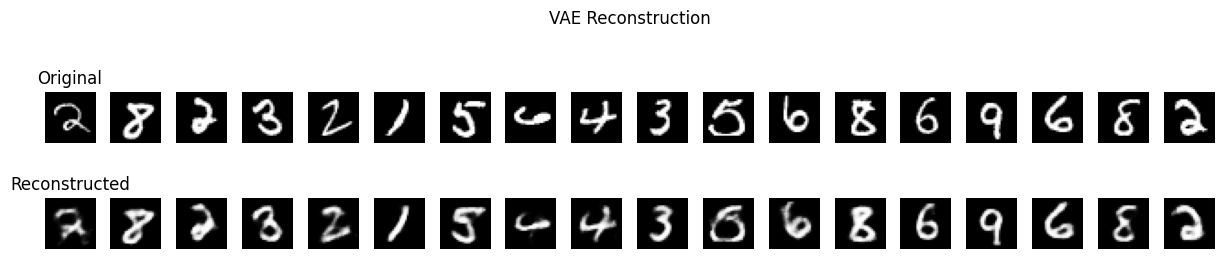

In [21]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 18, figsize=(12, 3))
for i in range(18):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


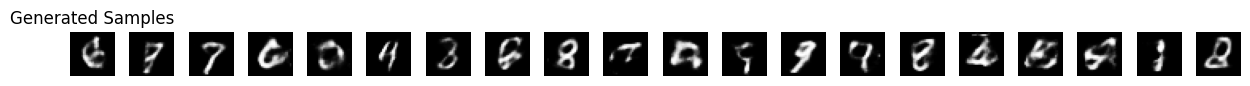

In [27]:
model.eval()
latent_dim = model.latent_dim  
# generate latent vector k latent vector z
k = 20  # Number of latent vectors to generate 
z = torch.randn(k, latent_dim).to(device)
with torch.no_grad():
    x_gen = model.decoder(z).view(k, 1, 28, 28).cpu()   
plt.figure(figsize=(12, 3))
for i in range(k):
    plt.subplot(2, k, i + 1)
    plt.imshow(x_gen[i, 0], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Generated Samples")
plt.tight_layout()
plt.show()

# CVAE

In [23]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 50
lr = 1e-3

# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(30000))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 193.0984
Epoch 2, Loss: 135.5119
Epoch 3, Loss: 122.6645
Epoch 4, Loss: 116.9619
Epoch 5, Loss: 113.4113
Epoch 6, Loss: 111.1075
Epoch 7, Loss: 109.4089
Epoch 8, Loss: 108.1803
Epoch 9, Loss: 107.0959
Epoch 10, Loss: 106.2291
Epoch 11, Loss: 105.5599
Epoch 12, Loss: 104.9782
Epoch 13, Loss: 104.4115
Epoch 14, Loss: 103.9886
Epoch 15, Loss: 103.5002
Epoch 16, Loss: 103.1958
Epoch 17, Loss: 102.8522
Epoch 18, Loss: 102.4900
Epoch 19, Loss: 102.1854
Epoch 20, Loss: 101.9792
Epoch 21, Loss: 101.7650
Epoch 22, Loss: 101.5212
Epoch 23, Loss: 101.2644
Epoch 24, Loss: 101.1245
Epoch 25, Loss: 100.9469
Epoch 26, Loss: 100.8033
Epoch 27, Loss: 100.5949
Epoch 28, Loss: 100.4756
Epoch 29, Loss: 100.3343
Epoch 30, Loss: 100.1925
Epoch 31, Loss: 100.0758
Epoch 32, Loss: 99.9327
Epoch 33, Loss: 99.7786
Epoch 34, Loss: 99.6795
Epoch 35, Loss: 99.5649
Epoch 36, Loss: 99.4876
Epoch 37, Loss: 99.3579
Epoch 38, Loss: 99.2982
Epoch 39, Loss: 99.2394
Epoch 40, Loss: 99.1127
Epoch 41, Loss: 99

In [24]:
# save the model to model_saved folder
sample_size = 30000
import os
if not os.path.exists("model_saved"):
    os.makedirs("model_saved")
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

Model saved to model_saved/cvae_mnist_30000.pth


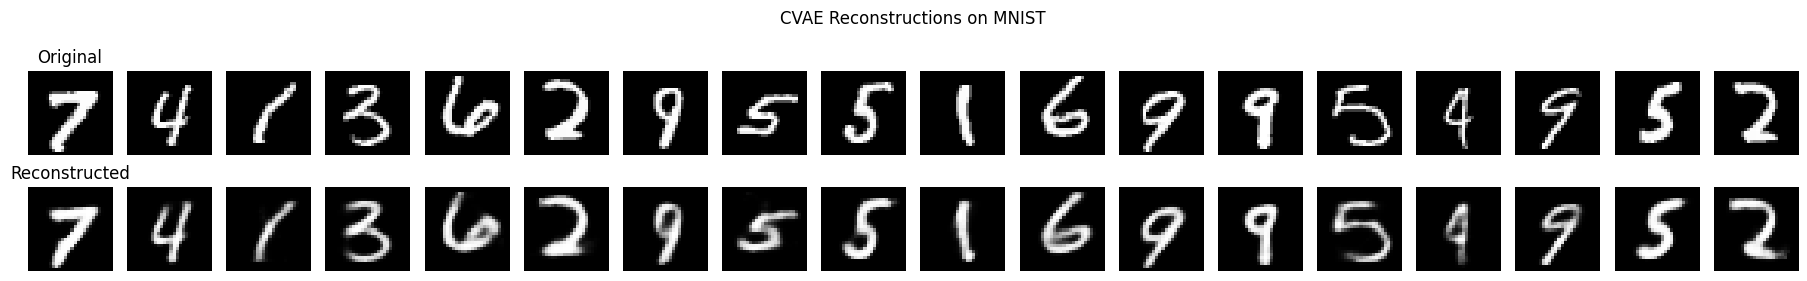

In [25]:
# Set model to evaluation mode
model.eval()

# Prepare test data
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

# Get a batch
x, y = next(iter(test_loader))
x = x.view(-1, 784).to(device)
y = F.one_hot(y, num_classes=10).float().to(device)

# Reconstruct images
with torch.no_grad():
    x_recon, _, _ = model(x, y)

# Move data to CPU for visualization
x = x.view(-1, 1, 28, 28).cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 18, figsize=(18, 3))
for i in range(18): 
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("CVAE Reconstructions on MNIST")
plt.tight_layout()
plt.show()


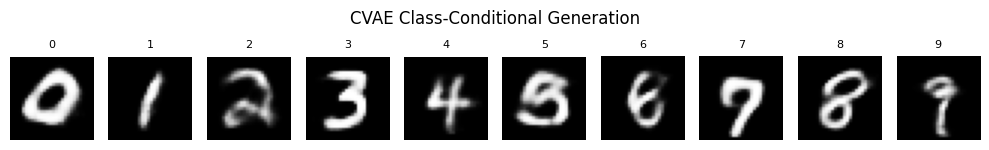

In [26]:
model.eval()

# Generate digits for labels 0 through 9
num_classes = 10
latent_dim = model.latent_dim
device = next(model.parameters()).device  # get model device

with torch.no_grad():
    # Sample one latent vector per class
    z = torch.randn(num_classes, latent_dim).to(device)

    # One-hot encode class labels 0-9
    y = torch.eye(num_classes).to(device)

    # Decode
    generated = model.decode(z, y).view(-1, 1, 28, 28).cpu()

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(num_classes, 1.5))
for i in range(num_classes):
    axes[i].imshow(generated[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(i), fontsize=8)
plt.suptitle("CVAE Class-Conditional Generation", fontsize=12)
plt.tight_layout()
plt.show()


## generate synthetic data

In [3]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os

latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
model.load_state_dict(torch.load("model_saved/cvae_mnist_30000.pth"))
model.eval()

/tmp/ipykernel_1604928/2441764426.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_30000.pth"))


CVAE(
  (fc1): Linear(in_features=794, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=30, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [4]:
import torch
import torch.nn.functional as F

model.eval()

n_per_class = 6000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]


In [ ]:
save_path = "data_saved/synthetic_mnist_cvae_60000.pt"
torch.save({
    'images': gen_imgs,    # Tensor [60000, 1, 28, 28]
    'labels': y            # Tensor [60000]
}, save_path)

print(f"Saved to {save_path}")


Saved to synthetic_mnist_cvae_60000.pt


/tmp/ipykernel_1604928/992744208.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")


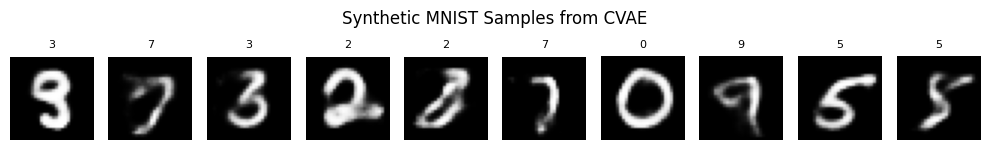

In [7]:
import matplotlib.pyplot as plt
data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")
images = data['images']   # [60000, 1, 28, 28]
labels = data['labels']   # [60000]

num_samples = 10
indices = torch.randperm(len(images))[:num_samples]

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 1.5))
for i, idx in enumerate(indices):
    axes[i].imshow(images[idx].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(labels[idx].item()), fontsize=8)
plt.suptitle("Synthetic MNIST Samples from CVAE", fontsize=12)
plt.tight_layout()
plt.show()

## Train the Discriminator

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset

# real MNIST (60,000）
transform = transforms.ToTensor()
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
real_imgs = torch.stack([mnist[i][0] for i in range(60000)])  # shape: [60000, 1, 28, 28]
real_labels = torch.ones(60000, 1)  # label = 1

# synthetic data（60,000）
data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")
fake_imgs = data['images'][:60000]  # shape: [60000, 1, 28, 28]
fake_labels = torch.zeros(60000, 1)  # label = 0

X_all = torch.cat([real_imgs, fake_imgs], dim=0)
y_all = torch.cat([real_labels, fake_labels], dim=0)

perm = torch.randperm(len(X_all))
X_all = X_all[perm]
y_all = y_all[perm]

from torch.utils.data import TensorDataset
disc_dataset = TensorDataset(X_all, y_all)
disc_loader = DataLoader(disc_dataset, batch_size=128, shuffle=True)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from discriminator import Discriminator
from torch import nn
D = Discriminator().to(device)
optimizer = torch.optim.Adam(D.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(10):

    D.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in disc_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        preds = D(x_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {acc*100:.2f}%")


Epoch 1, Loss: 75.4152, Accuracy: 96.59%
Epoch 2, Loss: 19.5794, Accuracy: 99.27%
Epoch 3, Loss: 15.7566, Accuracy: 99.40%
Epoch 4, Loss: 14.2092, Accuracy: 99.46%
Epoch 5, Loss: 10.0254, Accuracy: 99.63%
Epoch 6, Loss: 9.4177, Accuracy: 99.65%
Epoch 7, Loss: 9.0464, Accuracy: 99.67%
Epoch 8, Loss: 8.3308, Accuracy: 99.69%
Epoch 9, Loss: 8.1995, Accuracy: 99.71%
Epoch 10, Loss: 6.1267, Accuracy: 99.77%


In [11]:
save_path = "model_saved/discriminator_mnist_cvae.pth"
torch.save(D.state_dict(), save_path)

## Filter

In [ ]:
import torch
from torch.utils.data import DataLoader

D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae.pth"))
D.eval()

data = torch.load("data_saved/synthetic_mnist_cvae_60000.pt")
synthetic_images = data['images']  # [60000, 1, 28, 28]

synthetic_loader = DataLoader(synthetic_images, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)

print(f"Got probabilities for {all_probs.shape[0]} synthetic samples.")


/tmp/ipykernel_1604928/2089968998.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae.pth"))
/tmp/ipykerne

✅ Got probabilities for 60000 synthetic samples.


In [14]:
torch.save(all_probs, "data_saved/synthetic_mnist_cvae_probs.pt")
print("✅ Probabilities saved.")

✅ Probabilities saved.


/tmp/ipykernel_1604928/2390786294.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  probs = torch.load("data_saved/synthetic_mnist_cvae_probs.pt")  # shape: [60000, 1]


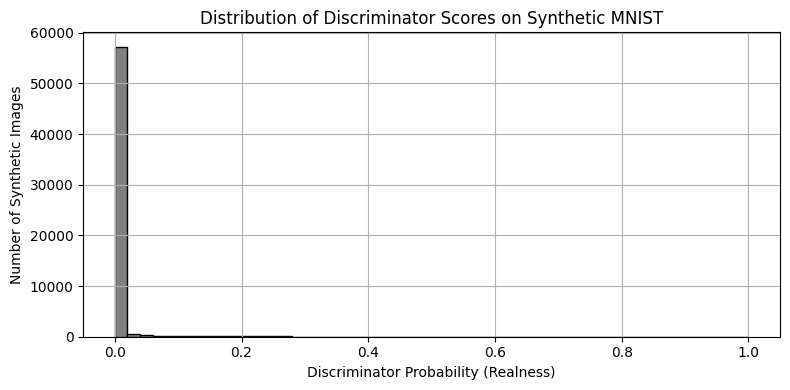

In [ ]:
import torch
import matplotlib.pyplot as plt

probs = torch.load("data_saved/synthetic_mnist_cvae_probs.pt")  # shape: [60000, 1]
probs = probs.squeeze().numpy()  # shape: [60000]

plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50, color='gray', edgecolor='black')
plt.xlabel("Discriminator Probability (Realness)")
plt.ylabel("Number of Synthetic Images")
plt.title("Distribution of Discriminator Scores on Synthetic MNIST")
plt.grid(True)
plt.tight_layout()
plt.show()
